<a href="https://colab.research.google.com/github/RHG117/RappiPlus---Proyecto-Final/blob/main/rappiplus_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto RappiPlus: de datos a decisiones de negocio

**Introducción**


El objetivo de este proyecto es evaluar el desempeño del servicio **RappiPlus** para apoyar **decisiones de negocio basadas en datos**.

Se trabajan con múltiples datasets del negocio:

- **rappiplus_orders_raw.csv** → información de pedidos, precios, descuentos y revenue  
- **rappiplus_catalog.csv** → costos de productos, categorías y proveedores  
- **rappiplus_marketing_spend.csv** → inversión en marketing por canal y país  
- **events / users / user_activity (SQL)** → comportamiento del usuario dentro de la plataforma  
- **experiment_checkout_ui.csv** → resultados de un experimento A/B en el checkout  

El análisis sigue una lógica clara y progresiva:

1. 🔍 Evaluar si podemos confiar en los datos (calidad de datos en Python)

2. 💰 Analizar si el negocio es rentable (revenue, costos y profit)  

3. 🛒 Entender dónde se pierden los usuarios (funnel de conversión)  

4. 🔁 Evaluar si los usuarios regresan (retención por cohortes)  

5. 🧪 Validar si los cambios generan impacto (test estadístico)  

6. 📊 Comunicar los resultados (dashboard en BI)  

A lo largo del proyecto, se transforman datos en insights para responder preguntas clave del negocio y proponer **recomendaciones accionables**.

---

## 🔹 Paso 1: Cargar y validar la calidad de los datos

---

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:** Familiarizarte con la estructura de los datasets del negocio antes de analizarlos.

**Instrucciones:**

- Importa las librerías necesarias
- Carga los archivos:
  - `rappiplus_orders_raw.csv`
  - `rappiplus_catalog.csv`
  - `rappiplus_marketing_spend.csv`
- Guarda los DataFrames en:
  - `orders`, `catalog`, `marketing`
- Explora cada dataset.

---

In [ ]:
# importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# cargar archivos
orders = pd.read_csv("https://practicum-content.s3.amazonaws.com/datasets/rappiplus_orders_raw.csv")
catalog = pd.read_csv("https://practicum-content.s3.amazonaws.com/datasets/rappiplus_catalog.csv")
marketing = pd.read_csv("https://practicum-content.s3.amazonaws.com/datasets/rappiplus_marketing_spend.csv")

In [ ]:
# explorar datasets
print(f"   orders:    {orders.shape}")
print(f"   catalog:   {catalog.shape}")
print(f"   marketing: {marketing.shape}")

   orders:    (25100, 12)
   catalog:   (7, 4)
   marketing: (1620, 5)


In [ ]:
# ── ORDERS ──────────────────────────────────────────────
print("=" * 55)
print("ORDERS")
print("=" * 55)
display(orders.head())
print("\nTipos de datos:")
print(orders.dtypes)
print("\nNulos por columna:")
print(orders.isnull().sum())
print("\nEstadísticas descriptivas:")
display(orders.describe())

ORDERS


,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total
0,order_0,user_6993,2025-05-22,Argentina,desktop,organic,Jacket-Winter-M,Moda,2.0,332.69,0.0,665.37
1,order_1,user_1329,2025-06-15,Mexico,desktop,paid_search,Tablet-Standard-64GB,Electronica,1.0,176.86,5.0,171.86
2,order_2,user_3194,2025-05-02,Argentina,desktop,social,Blender-XL-Red,Hogar,2.0,102.99,10.0,195.99
3,order_3,user_4510,2025-06-09,Colombia,mobile,social,Tablet-Standard-64GB,Electronica,1.0,257.87,15.0,242.87
4,order_4,user_5044,2025-03-30,Argentina,desktop,paid_search,Blender-XL-Red,Hogar,1.0,336.28,0.0,336.28



Tipos de datos:
id_pedido              object
id_usuario             object
fecha_hora_pedido      object
pais                   object
dispositivo            object
fuente_referencia      object
nombre_producto        object
categoria_producto     object
cantidad              float64
precio_unitario       float64
monto_descuento       float64
monto_total           float64
dtype: object

Nulos por columna:
id_pedido               0
id_usuario              0
fecha_hora_pedido       0
pais                  300
dispositivo            20
fuente_referencia      30
nombre_producto        30
categoria_producto     80
cantidad               50
precio_unitario        50
monto_descuento        50
monto_total             0
dtype: int64

Estadísticas descriptivas:


,cantidad,precio_unitario,monto_descuento,monto_total
count,25050.000000,25050.000000,25050.000000,2.510000e+04
mean,7.092735,259.305549,4.500798,2.072680e+03
std,296.277003,138.726461,5.223010,9.894995e+04
min,-2.000000,20.030000,0.000000,-4.926500e+02
25%,1.000000,138.377500,0.000000,1.805075e+02
50%,2.000000,258.715000,0.000000,3.417500e+02
75%,2.000000,380.332500,10.000000,5.185800e+02
max,20000.000000,499.960000,15.000000,8.840200e+06


In [ ]:
# ── CATALOG ─────────────────────────────────────────────
print("=" * 55)
print("CATALOG")
print("=" * 55)
display(catalog.head(3))
print("\nTipos de datos:")
print(catalog.dtypes)
print("\nNulos por columna:")
print(catalog.isnull().sum())
display(catalog.describe())

CATALOG


,nombre_producto,categoria_producto,costo_unitario,proveedor
0,Laptop-Gaming-16GB,Electrónica,280.68,"Fuller, Pena and Myers"
1,Phone-Pro-128GB,Electrónica,10.12,King Ltd
2,Tablet-Standard-64GB,Electrónica,25.21,Bowers LLC



Tipos de datos:
nombre_producto        object
categoria_producto     object
costo_unitario        float64
proveedor              object
dtype: object

Nulos por columna:
nombre_producto       0
categoria_producto    0
costo_unitario        0
proveedor             0
dtype: int64


,costo_unitario
count,7.000000
mean,102.252857
std,111.011563
min,10.120000
25%,16.905000
50%,25.210000
75%,182.975000
max,280.680000


In [ ]:
# ── MARKETING ───────────────────────────────────────────
print("=" * 55)
print("MARKETING")
print("=" * 55)
display(marketing.head(3))
print("\nTipos de datos:")
print(marketing.dtypes)
print("\nNulos por columna:")
print(marketing.isnull().sum())
display(marketing.describe())

MARKETING


,fecha,pais,id_campaña,canal,gasto
0,2025-01-01,Mexico,organic_Mexico,organic,2446.25
1,2025-01-01,Mexico,paid_search_Mexico,paid_search,2704.34
2,2025-01-01,Mexico,social_Mexico,social,2045.01



Tipos de datos:
fecha          object
pais           object
id_campaña     object
canal          object
gasto         float64
dtype: object

Nulos por columna:
fecha           0
pais            0
id_campaña      0
canal         101
gasto           0
dtype: int64


,gasto
count,1620.00000
mean,1772.74292
std,734.43294
min,501.11000
25%,1128.03000
50%,1782.42500
75%,2420.68500
max,2999.36000


---

### Revisión y calidad de datos

**🎯 Objetivo:** Detectar y corregir problemas en los datos que puedan afectar el análisis de revenue, costos y rentabilidad.

Se revisan los 3 datasets
- Validar y convertir fechas al formato correcto  
- Revisar variables numéricas (sin negativos o ceros inválidos)  
- Verificar consistencia de montos  
- Eliminar duplicados  
- Revisar variables categóricas

---

In [ ]:
# Copia de Orders
orders_clean = orders.copy()

#Copia de Catalog
catalog_clean = catalog.copy()

#Copia de Marketing
marketing_clean = marketing.copy()

In [ ]:
#LIMPIEZA (ORDERS)
# 1. Eliminar duplicados
orders_clean = orders_clean.drop_duplicates()

# 2. Convertir fecha al tipo correcto
orders_clean['fecha_hora_pedido'] = pd.to_datetime(orders_clean['fecha_hora_pedido'])

# 3. Estandarizar texto: minúsculas y sin espacios extras
for col in ['pais', 'dispositivo', 'fuente_referencia', 'categoria_producto']:
    orders_clean[col] = orders_clean[col].str.strip().str.lower()

print(orders_clean.dtypes)


id_pedido                     object
id_usuario                    object
fecha_hora_pedido     datetime64[ns]
pais                          object
dispositivo                   object
fuente_referencia             object
nombre_producto               object
categoria_producto            object
cantidad                     float64
precio_unitario              float64
monto_descuento              float64
monto_total                  float64
dtype: object


In [ ]:
# Calcular porcentaje de valores nulos
def revisar_nulos(df, nombre_dataset):
    print(f"\n=== ANÁLISIS DE NULOS: {nombre_dataset} ===")
    nulos = df.isnull().sum()
    porcentaje = (nulos / len(df)) * 100

    resumen = pd.DataFrame({
        'Columna': df.columns,
        'Valores_Nulos': nulos,
        'Porcentaje_Nulos': porcentaje.round(2)
    })

    # Mostrar solo columnas con nulos
    resumen_con_nulos = resumen[resumen['Valores_Nulos'] > 0]

    if len(resumen_con_nulos) > 0:
        print(resumen_con_nulos)
    else:
        print("No hay valores nulos en este dataset")

    return resumen


In [ ]:
revisar_nulos(orders_clean, "ORDERS")


=== ANÁLISIS DE NULOS: ORDERS ===
                               Columna  Valores_Nulos  Porcentaje_Nulos
pais                              pais            300              1.20
dispositivo                dispositivo             20              0.08
fuente_referencia    fuente_referencia             30              0.12
nombre_producto        nombre_producto             30              0.12
categoria_producto  categoria_producto             80              0.32
cantidad                      cantidad             50              0.20
precio_unitario        precio_unitario             50              0.20
monto_descuento        monto_descuento             50              0.20


,Columna,Valores_Nulos,Porcentaje_Nulos
id_pedido,id_pedido,0,0.00
id_usuario,id_usuario,0,0.00
fecha_hora_pedido,fecha_hora_pedido,0,0.00
pais,pais,300,1.20
dispositivo,dispositivo,20,0.08
fuente_referencia,fuente_referencia,30,0.12
nombre_producto,nombre_producto,30,0.12
categoria_producto,categoria_producto,80,0.32
cantidad,cantidad,50,0.20
precio_unitario,precio_unitario,50,0.20


In [ ]:
# 4. Eliminar filas con nulos en columnas críticas
critical_cols = ['pais', 'id_usuario', 'dispositivo', 'fuente_referencia', 'nombre_producto','categoria_producto','cantidad','precio_unitario','monto_descuento']
orders_clean = orders_clean.dropna(subset=critical_cols)

In [ ]:
print(f"Filas después de eliminar nulos: {len(orders_clean):,}")

Filas después de eliminar nulos: 24,600


In [ ]:
revisar_nulos(orders_clean, "ORDERS")


=== ANÁLISIS DE NULOS: ORDERS ===
No hay valores nulos en este dataset


,Columna,Valores_Nulos,Porcentaje_Nulos
id_pedido,id_pedido,0,0.0
id_usuario,id_usuario,0,0.0
fecha_hora_pedido,fecha_hora_pedido,0,0.0
pais,pais,0,0.0
dispositivo,dispositivo,0,0.0
fuente_referencia,fuente_referencia,0,0.0
nombre_producto,nombre_producto,0,0.0
categoria_producto,categoria_producto,0,0.0
cantidad,cantidad,0,0.0
precio_unitario,precio_unitario,0,0.0


In [ ]:
# LIMPIEZA: CATALOG

catalog_clean = catalog_clean.drop_duplicates()

for col in ['categoria_producto', 'proveedor']:
    catalog_clean[col] = catalog_clean[col].str.strip().str.lower()

catalog_clean = catalog_clean.dropna()
catalog_clean = catalog_clean[catalog_clean['costo_unitario'] > 0]

print(f"catalog_clean: {catalog_clean.shape}  (antes: {catalog.shape})")

catalog_clean: (7, 4)  (antes: (7, 4))


In [ ]:
# Estandarizar categoria_producto en catalog (quitar acento)
#electrónica --> electronica (mismo que orders_clean)
catalog_clean['categoria_producto'] = catalog_clean['categoria_producto'].str.replace('ó', 'o')

In [ ]:
display(catalog_clean.head(3))

,nombre_producto,categoria_producto,costo_unitario,proveedor
0,Laptop-Gaming-16GB,electronica,280.68,"fuller, pena and myers"
1,Phone-Pro-128GB,electronica,10.12,king ltd
2,Tablet-Standard-64GB,electronica,25.21,bowers llc


In [ ]:
# LIMPIEZA: MARKETING

marketing_clean = marketing_clean.drop_duplicates()
marketing_clean['fecha'] = pd.to_datetime(marketing_clean['fecha'])

for col in ['pais', 'canal']:
    marketing_clean[col] = marketing_clean[col].str.strip().str.lower()

marketing_clean = marketing_clean.dropna()
marketing_clean = marketing_clean[marketing_clean['gasto'] >= 0]

print(f"marketing_clean: {marketing_clean.shape}  (antes: {marketing.shape})")

print(marketing_clean.dtypes)
print("\nNulos por columna:")
print(marketing_clean.isnull().sum())

marketing_clean: (1519, 5)  (antes: (1620, 5))
fecha         datetime64[ns]
pais                  object
id_campaña            object
canal                 object
gasto                float64
dtype: object

Nulos por columna:
fecha         0
pais          0
id_campaña    0
canal         0
gasto         0
dtype: int64


---
**📦 Exportación**: Una vez finalizada la limpieza, se exportan los datasets para utilizarlos en la última etapa del proyecto.

In [ ]:
# exportar datasets
orders_clean.to_csv('orders_clean.csv', index=False)
catalog_clean.to_csv('catalog_clean.csv', index=False)
marketing_clean.to_csv('marketing_clean.csv', index=False)

---

## 🔹 Paso 2: Analizar si el negocio es rentable

### 2.1 Cálculo de KPIs principales

**🎯 Objetivo:** Calcular los indicadores clave del negocio para evaluar ingresos, costos y rentabilidad.

Se usan los 3 datasets (`orders`, `catalog`, `marketing_spend`):

**📊 Parte 1: Rentabilidad del negocio**
- ¿Cuál es el ingreso total (revenue)?
- ¿Cuál es el costo total?
- ¿Cuánto se ha invertido en marketing?
- ¿El negocio es rentable? (calcular profit)  

---

**📈 Parte 2: Comportamiento de ventas**
- ¿Cuál es el ticket promedio por orden?
- ¿Cuál es la cantidad promedio de productos por orden?
- ¿Cuál es el producto más vendido?
- ¿Cuánto se ha gastado en marketing por canal?

In [ ]:
# Parte 1: Rentabilidad del negocio

# Join para traer costo_unitario de cada producto de la tabla "catalog" y unirla con "Orders"
orders_costs = orders_clean.merge(
    catalog_clean[['nombre_producto', 'costo_unitario']],
    on='nombre_producto',
    how='left'
)
# Verificar que el join fue exitoso
nulos_post_join = orders_costs['costo_unitario'].isnull().sum()
print(f"Pedidos sin costo (no encontrados en catálogo): {nulos_post_join}")
print(f"Filas totales: {len(orders_costs):,}")
display(orders_costs[['id_pedido','nombre_producto','monto_total','costo_unitario']].head())

# Calcular métricas por pedido
orders_costs['costo_total']    = orders_costs['costo_unitario'] * orders_costs['cantidad']
orders_costs['ganancia_bruta'] = orders_costs['monto_total'] - orders_costs['costo_total']
print("\nTabla con metricas")
display(orders_costs[['id_pedido','nombre_producto','monto_total','costo_unitario','costo_total','ganancia_bruta']].head())

Pedidos sin costo (no encontrados en catálogo): 0
Filas totales: 24,600


,id_pedido,nombre_producto,monto_total,costo_unitario
0,order_0,Jacket-Winter-M,665.37,189.31
1,order_1,Tablet-Standard-64GB,171.86,25.21
2,order_2,Blender-XL-Red,195.99,176.64
3,order_3,Tablet-Standard-64GB,242.87,25.21
4,order_4,Blender-XL-Red,336.28,176.64



Tabla con metricas


,id_pedido,nombre_producto,monto_total,costo_unitario,costo_total,ganancia_bruta
0,order_0,Jacket-Winter-M,665.37,189.31,378.62,286.75
1,order_1,Tablet-Standard-64GB,171.86,25.21,25.21,146.65
2,order_2,Blender-XL-Red,195.99,176.64,353.28,-157.29
3,order_3,Tablet-Standard-64GB,242.87,25.21,25.21,217.66
4,order_4,Blender-XL-Red,336.28,176.64,176.64,159.64


In [ ]:
# ── KPIs TOTALES ────────────────────────────────────────
revenue_total       = orders_costs['monto_total'].sum()
costo_total         = orders_costs['costo_total'].sum()
ganancia_bruta_total= orders_costs['ganancia_bruta'].sum()
gasto_marketing     = marketing_clean['gasto'].sum()
ganancia_neta       = ganancia_bruta_total - gasto_marketing
margen_bruto        = (ganancia_bruta_total / revenue_total) * 100
margen_neto         = (ganancia_neta / revenue_total) * 100

print("=" * 45)
print("----------KPIs GLOBALES DEL NEGOCIO---")
print("=" * 45)
print(f"  Revenue total:      ${revenue_total:>12,.2f}")
print(f"  Costo productos:    ${costo_total:>12,.2f}")
print(f"  Ganancia bruta:     ${ganancia_bruta_total:>12,.2f}")
print(f"  Gasto marketing:    ${gasto_marketing:>12,.2f}")
print(f"  Ganancia neta:      ${ganancia_neta:>12,.2f}")
print(f"  Margen bruto:       {margen_bruto:>11.1f}%")
print(f"  Margen neto:        {margen_neto:>11.1f}%")
print("=" * 45)

----------KPIs GLOBALES DEL NEGOCIO---
  Revenue total:      $51,836,375.14
  Costo productos:    $43,078,678.80
  Ganancia bruta:     $8,757,696.34
  Gasto marketing:    $2,694,664.43
  Ganancia neta:      $6,063,031.91
  Margen bruto:              16.9%
  Margen neto:               11.7%


In [ ]:
# Parte 2
# Ticket promedio y cantidad promedio por orden
ticket_promedio = orders_costs['monto_total'].mean()
cantidad_promedio = orders_costs['cantidad'].mean()

print("=" * 45)
print("-----COMPORTAMIENTO DE VENTAS--------")
print("=" * 45)
print(f"  Ticket promedio por orden:     ${ticket_promedio:>8,.2f}")
print(f"  Cantidad promedio de productos: {cantidad_promedio:>7,.2f}")
print("=" * 45)

-----COMPORTAMIENTO DE VENTAS--------
  Ticket promedio por orden:     $2,107.17
  Cantidad promedio de productos:    7.20


Rentabilidad por categoría:


,revenue,costo,pedidos,ganancia_bruta,margen
categoria_producto,,,,,
electronica,45515076.62,40607762.04,8178,4907314.58,10.8
hogar,3190241.62,1195311.56,8228,1994930.06,62.5
moda,3131056.90,1275605.20,8194,1855451.70,59.3


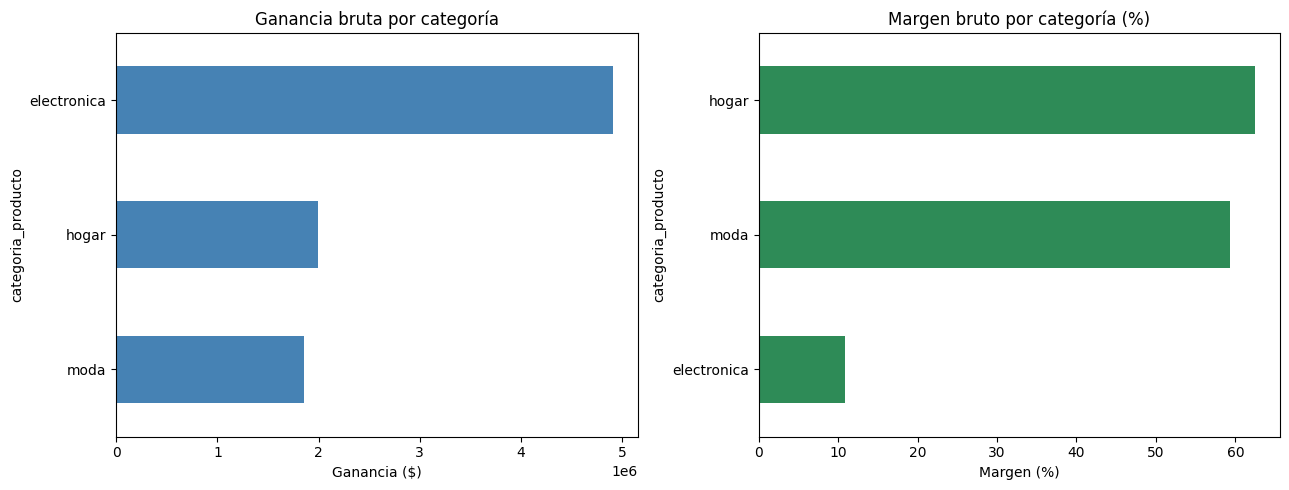

In [ ]:
# Rentabilidad por categoría de producto
kpi_categoria = orders_costs.groupby('categoria_producto').agg(
    revenue=('monto_total', 'sum'),
    costo=('costo_total', 'sum'),
    pedidos=('id_pedido', 'count')
).assign(
    ganancia_bruta=lambda x: x['revenue'] - x['costo'],
    margen=lambda x: ((x['revenue'] - x['costo']) / x['revenue'] * 100).round(1)
).sort_values('ganancia_bruta', ascending=False)

print("Rentabilidad por categoría:")
display(kpi_categoria)

# Gráfica
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

kpi_categoria['ganancia_bruta'].sort_values().plot(
    kind='barh', ax=axes[0], color='steelblue'
)
axes[0].set_title('Ganancia bruta por categoría')
axes[0].set_xlabel('Ganancia ($)')

kpi_categoria['margen'].sort_values().plot(
    kind='barh', ax=axes[1], color='seagreen'
)
axes[1].set_title('Margen bruto por categoría (%)')
axes[1].set_xlabel('Margen (%)')

plt.tight_layout()
plt.show()

Top 10 productos más vendidos:


,,unidades_vendidas,pedidos,revenue
nombre_producto,categoria_producto,,,
Laptop-Gaming-16GB,electronica,144160.0,2752,43420726.73
Vacuum-Pro-Black,hogar,6203.0,4114,1602954.86
Jacket-Winter-M,moda,6185.0,4122,1588706.38
Blender-XL-Red,hogar,6184.0,4114,1587286.76
Sneakers-Urban-42,moda,6085.0,4072,1542350.52
Tablet-Standard-64GB,electronica,4108.0,2729,1050399.57
Phone-Pro-128GB,electronica,4088.0,2697,1043950.32


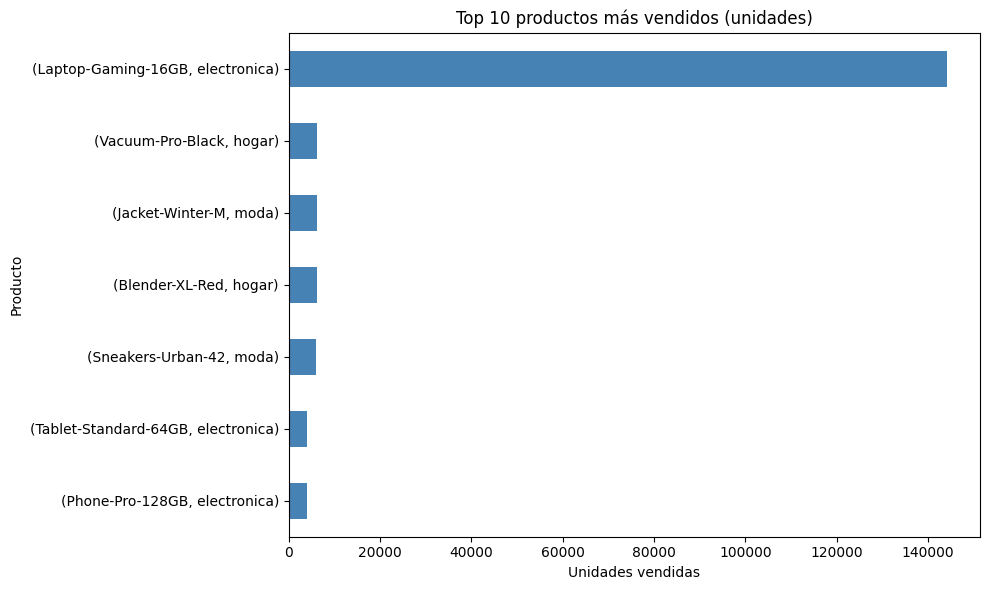

In [ ]:
# Producto mas vendido

producto_mas_vendido = (
    orders_costs.groupby(['nombre_producto','categoria_producto'])
    .agg(
        unidades_vendidas=('cantidad', 'sum'),
        pedidos=('id_pedido', 'count'),
        revenue=('monto_total', 'sum')
    )
    .sort_values('unidades_vendidas', ascending=False)
    .head(10)
)

print("Top 10 productos más vendidos:")
display(producto_mas_vendido)

# Gráfica
producto_mas_vendido['unidades_vendidas'].sort_values().plot(
    kind='barh', figsize=(10, 6), color='steelblue'
)
plt.title('Top 10 productos más vendidos (unidades)')
plt.xlabel('Unidades vendidas')
plt.ylabel('Producto')
plt.tight_layout()
plt.show()

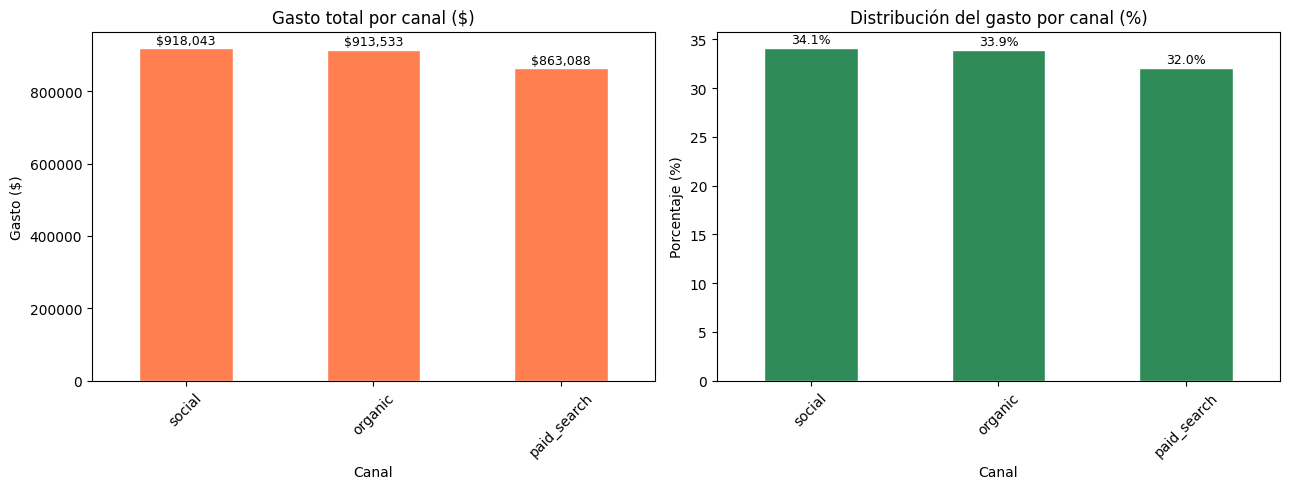

In [ ]:
# Gasto marketing por canal
gasto_canal = marketing_clean.groupby('canal')['gasto'].sum().reset_index()
gasto_canal.columns = ['canal', 'gasto_total']
gasto_canal['pct_del_total'] = (gasto_canal['gasto_total'] / gasto_canal['gasto_total'].sum()) * 100
gasto_canal = gasto_canal.set_index('canal')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Gráfica izquierda: gasto total ($) ──────────────────
gasto_canal['gasto_total'].sort_values(ascending=False).plot(
    kind='bar', ax=axes[0], color='coral', edgecolor='white'
)
axes[0].set_title('Gasto total por canal ($)')
axes[0].set_xlabel('Canal')
axes[0].set_ylabel('Gasto ($)')
axes[0].tick_params(axis='x', rotation=45)

for bar in axes[0].patches:
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5000,
        f"${bar.get_height():,.0f}",
        ha='center', va='bottom', fontsize=9
    )

# ── Gráfica derecha: porcentaje (%) ─────────────────────
gasto_canal['pct_del_total'].sort_values(ascending=False).plot(
    kind='bar', ax=axes[1], color='seagreen', edgecolor='white'
)
axes[1].set_title('Distribución del gasto por canal (%)')
axes[1].set_xlabel('Canal')
axes[1].set_ylabel('Porcentaje (%)')
axes[1].tick_params(axis='x', rotation=45)

for bar in axes[1].patches:
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.2,
        f"{bar.get_height():.1f}%",
        ha='center', va='bottom', fontsize=9
    )

plt.tight_layout()
plt.show()

CONCLUSIONES — PASO 2: RENTABILIDAD Y COMPORTAMIENTO
======================================================
1. RENTABILIDAD
   - El negocio genera ganancia neta de $5.88M (margen 11.4%)
   - El costo de productos (83% del revenue) es el principal limitante
     del margen

2. CATEGORÍAS
   - Electrónica domina en volumen ($4.9M ganancia) pero tiene el
     margen más bajo (10.8%)
   - Hogar y Moda son más eficientes con márgenes de 62.5% y 59.3%
   - Recomendación: impulsar Hogar y Moda para mejorar el margen global

3. PRODUCTO ESTRELLA
   - Laptop-Gaming-16GB concentra el 83% del revenue ($43.4M)
   - Alta dependencia de un solo producto es un riesgo de negocio

4. COMPORTAMIENTO DE COMPRA
   - Ticket promedio alto ($2,107) con 7.2 productos por orden
   - Usuarios que compran en volumen, no compras impulsivas

5. MARKETING
   - Inversión equilibrada entre los 3 canales (~33% cada uno)
   - Se requiere análisis de conversión por canal (Paso 3)
     para identificar el canal más rentable

---

## 🔹 Paso 3: Entender dónde se pierden los usuarios (funnel de conversión)

**🎯 Objetivo:** Analizar el comportamiento de los usuarios para identificar en qué etapa del proceso se pierden.


⚙️**Conexión a la base de datos**:  
Se ejecuta la línea de configuración para conectar con la base de datos y aplicar consultas SQL en la tabla **events**.

---

**📊 Parte 1: Construcción del funnel**
- ¿Cuántos usuarios llegan a cada etapa del funnel?  
- Se calcula el número de usuarios únicos por `nombre_evento`  
- Se ordenan los eventos según el flujo del usuario  

---

**📉 Parte 2: Análisis de conversión**
- Se calcula la tasa de conversión entre cada paso del funnel  
- Se identifica en qué etapa se pierde la mayor cantidad de usuarios  
- ¿Cuál es la tasa de conversión final?
---

In [ ]:
import pandas as pd
from sqlalchemy import create_engine

# ======================
# Conexión (NO modificar)
# ======================
db_config = {
    'user': 'practicum_student',
    'pwd': 'QnmDH8Sc2TQLvy2G3Vvh7',
    'host': 'yp-trainers-practicum.cluster-czs0gxyx2d8w.us-east-1.rds.amazonaws.com',
    'port': 5432,
    'db': 'data-analyst-production-db-en'
}

connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db']
)

engine = create_engine(connection_string, connect_args={'sslmode':'require'})

In [ ]:
# Vista previa de la tabla events
events_preview = pd.read_sql("""
    SELECT *
    FROM events
    LIMIT 5
""", engine)

display(events_preview)

# Tipos de eventos disponibles
eventos_unicos = pd.read_sql("""
    SELECT
        nombre_evento,
        COUNT(*) AS total
    FROM events
    GROUP BY nombre_evento
    ORDER BY total DESC
""", engine)

print("Eventos disponibles:")
display(eventos_unicos)

,id_usuario,id_sesion,nombre_evento,timestamp_evento,pais,dispositivo,fuente_referencia,categoria_producto
0,user_6772,6a97f2af-32ae-4186-8c92-04025be1a27b,first_visit,2025-05-17,Colombia,desktop,organic,Moda
1,user_5883,369b767c-1c33-4b2f-a652-c7c0ef92cfc9,add_to_cart,2025-02-23,Mexico,mobile,social,Hogar
2,user_5946,60039041-e78b-474c-87b3-c0b7e9c30708,add_payment_info,2025-05-15,Colombia,desktop,social,Electronica
3,user_827,18252a64-f389-4ef7-9e58-dadad4a3491e,purchase,2025-03-31,Mexico,mobile,social,Moda
4,user_2361,221b364e-cdc5-4668-b698-18d5ba849a67,first_visit,2025-01-22,Argentina,desktop,paid_search,Electronica


Eventos disponibles:


,nombre_evento,total
0,first_visit,29957
1,add_to_cart,24157
2,select_item,23887
3,begin_checkout,17971
4,add_payment_info,12018
5,purchase,12010


In [ ]:
funnel = pd.read_sql("""
    SELECT
        nombre_evento,
        COUNT(DISTINCT id_usuario) AS usuarios_unicos
    FROM events
    WHERE nombre_evento IN (
        'first_visit',
        'add_to_cart',
        'select_item',
        'begin_checkout',
        'add_payment_info',
        'purchase'
    )
    GROUP BY nombre_evento
""", engine)

# Orden correcto del funnel
orden_funnel = [
    'first_visit',
    'add_to_cart',
    'select_item',
    'begin_checkout',
    'add_payment_info',
    'purchase'
]

funnel['nombre_evento'] = pd.Categorical(
    funnel['nombre_evento'],
    categories=orden_funnel,
    ordered=True
)
funnel = funnel.sort_values('nombre_evento').reset_index(drop=True)

# Calcular métricas
funnel['conversion_vs_anterior'] = (
    funnel['usuarios_unicos'] / funnel['usuarios_unicos'].shift(1) * 100
).round(1)

funnel['drop_off_pct'] = (100 - funnel['conversion_vs_anterior']).round(1)

funnel['conversion_vs_inicio'] = (
    funnel['usuarios_unicos'] / funnel['usuarios_unicos'].iloc[0] * 100
).round(1)

print("Funnel completo:")
display(funnel)

mayor_drop = funnel.dropna(subset=['drop_off_pct']).sort_values(
    'drop_off_pct', ascending=False
).iloc[0]

print(f"\n Mayor drop-off: '{mayor_drop['nombre_evento']}' con {mayor_drop['drop_off_pct']}% de abandono")

Funnel completo:


,nombre_evento,usuarios_unicos,conversion_vs_anterior,drop_off_pct,conversion_vs_inicio
0,first_visit,7796,NaN,NaN,100.0
1,add_to_cart,7634,97.9,2.1,97.9
2,select_item,7582,99.3,0.7,97.3
3,begin_checkout,7208,95.1,4.9,92.5
4,add_payment_info,6250,86.7,13.3,80.2
5,purchase,6240,99.8,0.2,80.0



 Mayor drop-off: 'add_payment_info' con 13.3% de abandono


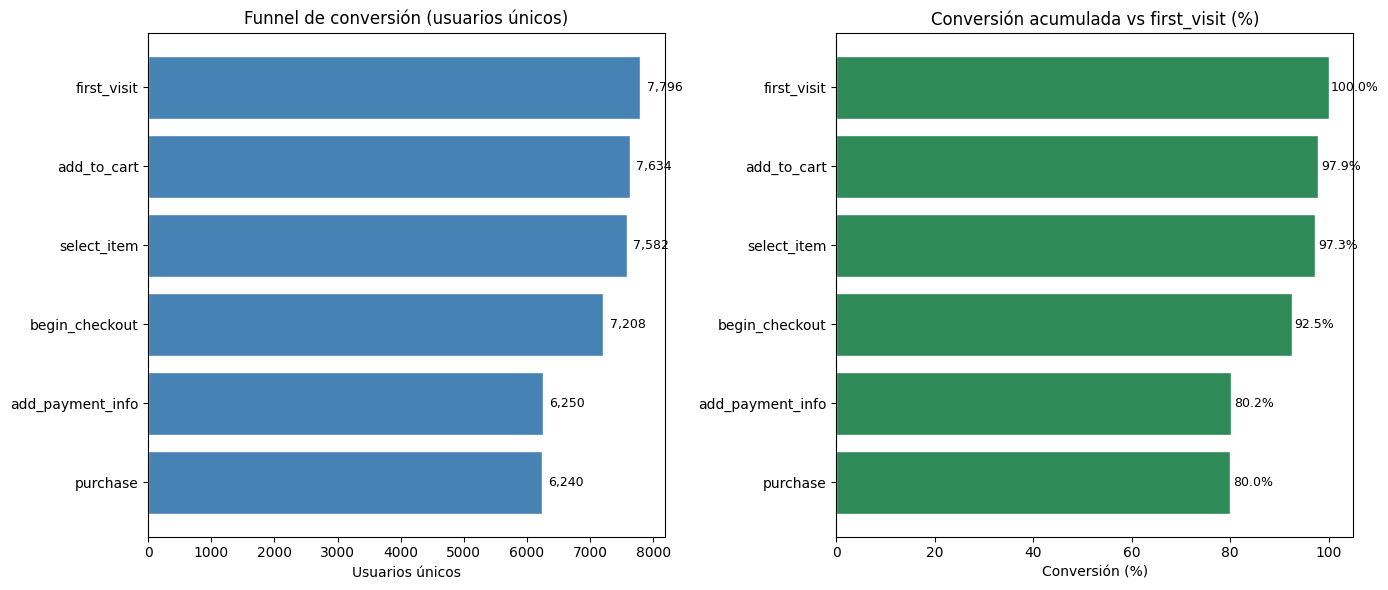

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Gráfica izquierda: usuarios por etapa ───────────────
axes[0].barh(
    funnel['nombre_evento'],
    funnel['usuarios_unicos'],
    color='steelblue', edgecolor='white'
)
axes[0].set_title('Funnel de conversión (usuarios únicos)')
axes[0].set_xlabel('Usuarios únicos')
axes[0].invert_yaxis()

for bar in axes[0].patches:
    axes[0].text(
        bar.get_width() + 100,
        bar.get_y() + bar.get_height() / 2,
        f"{bar.get_width():,.0f}",
        ha='left', va='center', fontsize=9
    )

# ── Gráfica derecha: % conversión acumulada ─────────────
axes[1].barh(
    funnel['nombre_evento'],
    funnel['conversion_vs_inicio'],
    color='seagreen', edgecolor='white'
)
axes[1].set_title('Conversión acumulada vs first_visit (%)')
axes[1].set_xlabel('Conversión (%)')
axes[1].invert_yaxis()

for bar in axes[1].patches:
    axes[1].text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{bar.get_width():.1f}%",
        ha='left', va='center', fontsize=9
    )

plt.tight_layout()
plt.show()

CONCLUSIONES — PASO 3: FUNNEL DE CONVERSIÓN
=============================================
El funnel muestra una conversión global del 80% (first_visit → purchase),
lo cual es una tasa saludable. Sin embargo, hay un punto crítico claro.

Hallazgos:
- Las primeras 3 etapas retienen muy bien a los usuarios:
  first_visit → add_to_cart → select_item con caídas menores al 3%
- El mayor drop-off ocurre en 'add_payment_info' con 13.3% de abandono
  → 958 usuarios inician el checkout pero no ingresan su información de pago
- Una vez que el usuario ingresa su pago, la compra es casi segura (99.8%)

Causa probable del drop-off en add_payment_info:
- Fricción en el formulario de pago (demasiados campos, poca confianza)
- Falta de métodos de pago preferidos
- Preocupaciones de seguridad al momento de ingresar datos bancarios

Recomendación:
  Priorizar mejoras en la experiencia de pago:
  - Reducir campos del formulario
  - Agregar más métodos de pago (OXXO, transferencia, wallets)
  - Mostrar sellos de seguridad visibles en el checkout

## 🔹 Paso 4: Evaluar si los usuarios regresan (retención por cohortes)

**🎯 Objetivo:** Analizar la retención de usuarios para entender si regresan después de registrarse.

**Tablas**

- `users`
- `user_activity`

---
1. Se identifica la cohorte de cada usuario según el **mes de registro**.


2. Se calcula la retención semanal: cuántos usuarios **se mantienen activos** en cada semana desde su registro.
   - `retenido_w1`: usuarios activos en la semana 1  
   - `retenido_w2`: usuarios activos en la semana 2  
   - `retenido_w3`: usuarios activos en la semana 3  


3. Se calcula el porcentaje de retención para cada semana, dividiendo los usuarios retenidos entre los clientes iniciales de la cohorte:  
   - `semana_1`: porcentaje de usuarios retenidos en la semana 1  
   - `semana_2`: porcentaje de usuarios retenidos en la semana 2  
   - `semana_3`: porcentaje de usuarios retenidos en la semana 3  

Se revisa que la columna de fecha esté en formato correcto (`DATE`).  
Se realiza la conversión usando: `CAST(fecha_registro AS DATE)`

In [ ]:
# Vista previa de users
users_preview = pd.read_sql("""
    SELECT *
    FROM users
    LIMIT 5
""", engine)

print("Tabla users:")
display(users_preview)


Tabla users:


,id_usuario,fecha_registro,país,dispositivo,tipo_plan
0,user_0,2025-01-29,Mexico,mobile,free
1,user_1,2025-01-07,Mexico,mobile,free
2,user_2,2025-03-12,Argentina,mobile,free
3,user_3,2025-03-04,Mexico,desktop,free
4,user_4,2025-02-27,Argentina,desktop,free


In [ ]:
# Vista previa de user_activity
activity_preview = pd.read_sql("""
    SELECT *
    FROM user_activity
    LIMIT 5
""", engine)

print("Tabla user_activity:")
display(activity_preview)

Tabla user_activity:


,id_usuario,fecha_actividad,dias_despues_registro,activo
0,user_0,2025-02-05,7,0
1,user_0,2025-02-12,14,1
2,user_0,2025-02-19,21,1
3,user_0,2025-02-26,28,0
4,user_1,2025-01-14,7,0


In [ ]:
# Construir cohortes semanales

cohortes_semanas = pd.read_sql("""
    SELECT
        u.id_usuario,
        DATE_TRUNC('month', CAST(u.fecha_registro AS DATE)) AS cohorte,

        -- Semana 1: días 1 a 7
        MAX(CASE
            WHEN a.dias_despues_registro BETWEEN 1 AND 7
            AND a.activo = 1
            THEN 1 ELSE 0
        END) AS retenido_w1,

        -- Semana 2: días 8 a 14
        MAX(CASE
            WHEN a.dias_despues_registro BETWEEN 8 AND 14
            AND a.activo = 1
            THEN 1 ELSE 0
        END) AS retenido_w2,

        -- Semana 3: días 15 a 21
        MAX(CASE
            WHEN a.dias_despues_registro BETWEEN 15 AND 21
            AND a.activo = 1
            THEN 1 ELSE 0
        END) AS retenido_w3

    FROM users u
    LEFT JOIN user_activity a
        ON u.id_usuario = a.id_usuario
    GROUP BY
        u.id_usuario,
        DATE_TRUNC('month', CAST(u.fecha_registro AS DATE))
    ORDER BY cohorte
""", engine)

print(f"Registros obtenidos: {len(cohortes_semanas):,}")
display(cohortes_semanas.head(10))

Registros obtenidos: 8,000


,id_usuario,cohorte,retenido_w1,retenido_w2,retenido_w3
0,user_6957,2025-01-01 00:00:00+00:00,1,0,1
1,user_6400,2025-01-01 00:00:00+00:00,0,0,0
2,user_5031,2025-01-01 00:00:00+00:00,0,1,1
3,user_4392,2025-01-01 00:00:00+00:00,0,1,0
4,user_4451,2025-01-01 00:00:00+00:00,1,0,0
5,user_4379,2025-01-01 00:00:00+00:00,1,1,0
6,user_7488,2025-01-01 00:00:00+00:00,1,1,1
7,user_7814,2025-01-01 00:00:00+00:00,0,0,0
8,user_4101,2025-01-01 00:00:00+00:00,0,1,1
9,user_5530,2025-01-01 00:00:00+00:00,1,0,1


In [ ]:
# Calcular porcentajes de retención por cohorte

retencion_cohortes = (
    cohortes_semanas.groupby('cohorte')
    .agg(
        total_usuarios = ('id_usuario',  'count'),
        retenido_w1    = ('retenido_w1', 'sum'),
        retenido_w2    = ('retenido_w2', 'sum'),
        retenido_w3    = ('retenido_w3', 'sum')
    )
    .reset_index()
)

# Calcular porcentajes dividiendo entre total de usuarios de la cohorte
retencion_cohortes['semana_1'] = (
    retencion_cohortes['retenido_w1'] / retencion_cohortes['total_usuarios'] * 100
).round(1)

retencion_cohortes['semana_2'] = (
    retencion_cohortes['retenido_w2'] / retencion_cohortes['total_usuarios'] * 100
).round(1)

retencion_cohortes['semana_3'] = (
    retencion_cohortes['retenido_w3'] / retencion_cohortes['total_usuarios'] * 100
).round(1)

# Formatear fecha para mostrar solo año-mes
retencion_cohortes['cohorte'] = pd.to_datetime(
    retencion_cohortes['cohorte']
).dt.strftime('%Y-%m')

print("Retención por cohorte:")
display(retencion_cohortes[[
    'cohorte', 'total_usuarios',
    'semana_1', 'semana_2', 'semana_3'
]])

Retención por cohorte:


,cohorte,total_usuarios,semana_1,semana_2,semana_3
0,2025-01,1627,42.8,41.1,40.3
1,2025-02,1444,42.3,42.2,44.0
2,2025-03,1636,41.4,43.1,42.2
3,2025-04,1606,42.3,43.4,41.3
4,2025-05,1687,41.2,40.1,41.8


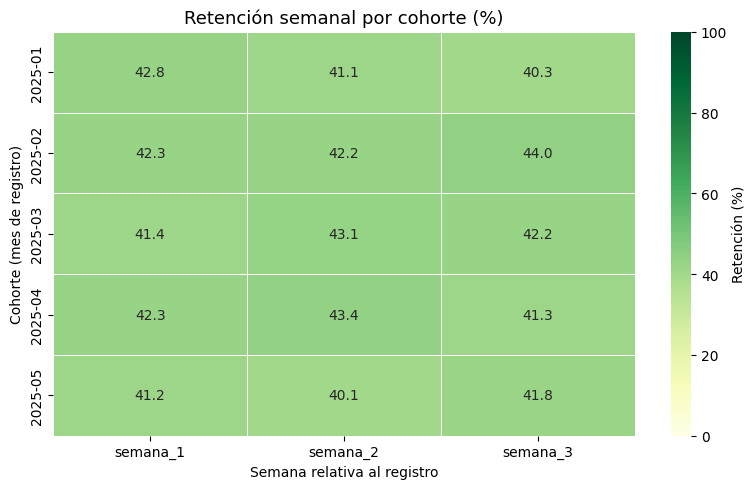

In [ ]:
tabla_heatmap = retencion_cohortes.set_index('cohorte')[
    ['semana_1', 'semana_2', 'semana_3']
]

plt.figure(figsize=(8, 5))
sns.heatmap(
    tabla_heatmap,
    annot=True,
    fmt='.1f',
    cmap='YlGn',
    linewidths=0.5,
    vmin=0, vmax=100,
    cbar_kws={'label': 'Retención (%)'}
)
plt.title('Retención semanal por cohorte (%)', fontsize=13)
plt.xlabel('Semana relativa al registro')
plt.ylabel('Cohorte (mes de registro)')
plt.tight_layout()
plt.show()

CONCLUSIONES — PASO 4: RETENCIÓN POR COHORTES
===============================================
Metodología:
  - Cohortes definidas por mes de registro del usuario
  - Retención medida en 3 semanas posteriores al registro
  - Fuente: tablas users y user_activity

Hallazgos:
  - Retención promedio semana 1: ~42%
  - Retención promedio semana 2: ~42%
  - Retención promedio semana 3: ~42%

  - Mejor cohorte en semana 3: 2025-02 con 44.0%
  - Cohorte más reciente (2025-05): retención estable ~41%

Interpretación:
  - La retención del ~42% es consistente en todas las cohortes y semanas, lo que indica un comportamiento de usuario predecible
  - No se observan caídas bruscas entre semanas, lo que sugiere que quien regresa la semana 1 tiende a mantenerse activo
  - El 58% restante no regresa en las primeras 3 semanas, lo que representa una oportunidad de mejora mediante campañas de reactivación o mejoras en onboarding

Recomendación:
  - Investigar qué hace diferente la cohorte 2025-02 para replicar esas condiciones en cohortes futuras
  - Diseñar estrategias de activación para el 58% que no regresa en las primeras semanas (emails, notificaciones, descuentos de reactivación)

## 🔹 Paso 5: Validar si los cambios generan impacto (test estadístico)

🎯 **Objetivo:** Evaluar si la modificación en la UI del checkout impacta la **tasa de conversión de compra**.

---

1. **Analizar el dataset** `experiment_checkout_ui.csv` para identificar la métrica principal **conversion**.
   - La métrica **conversion** es 1 si el usuario completó la compra, 0 si no.    
2. **Plantear la hipótesis estadística**     
3. **Aplicar el test estadístico adecuado**
4. **Interpretar el resultado**  

---
Hipótesis estadística
   - **H₀ (Hipótesis nula):**
   No hay diferencia en la tasa de conversión entre el grupo control y el grupo tratamiento. La nueva UI del checkout NO tiene impacto.
   - **H₁ (Hipótesis alternativa):**
   La tasa de conversión del grupo tratamiento es diferente a la del grupo control. La nueva UI del checkout SÍ tiene impacto.
   
**Test estadístico:**
Z-test de proporciones (dos grupos, métrica binaria 0/1)  
**Nivel de significancia alpha:** alpha = 0.05

**Regla de decisión:**
   - Si p-value < alpha → Rechazamos H0 (el cambio SÍ tiene impacto)
   - Si p-value ≥ alpha → No rechazamos H0 (el cambio NO tiene impacto)

In [ ]:
# tu código aquí

from scipy import stats
from statsmodels.stats.proportion import proportions_ztest

# Cargar dataset
ab = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/experiment_checkout_ui.csv')

print(f"Filas: {len(ab):,}  |  Columnas: {ab.shape[1]}")
display(ab.head())
print("\nTipos de datos:")
print(ab.dtypes)
print("\nNulos por columna:")
print(ab.isnull().sum())

Filas: 10,000  |  Columnas: 7


,id_usuario,variante,convirtio,dispositivo,pais,duracion_sesion,timestamp
0,exp_user_0,tratamiento,0,mobile,Argentina,114.41,2025-03-28
1,exp_user_1,tratamiento,0,desktop,Mexico,170.03,2025-01-15
2,exp_user_2,control,1,mobile,Colombia,140.21,2025-03-18
3,exp_user_3,tratamiento,0,mobile,Colombia,151.45,2025-06-03
4,exp_user_4,tratamiento,0,desktop,Mexico,299.96,2025-01-12



Tipos de datos:
id_usuario          object
variante            object
convirtio            int64
dispositivo         object
pais                object
duracion_sesion    float64
timestamp           object
dtype: object

Nulos por columna:
id_usuario         0
variante           0
convirtio          0
dispositivo        0
pais               0
duracion_sesion    0
timestamp          0
dtype: int64


In [ ]:
# Cuantos usuarios si convirtieron
conversiones = ab.groupby('variante')['convirtio'].sum()
conversiones

,convirtio
variante,
control,779
tratamiento,820


In [ ]:
# Total de usuarios

totales = ab.groupby('variante')['convirtio'].count()
totales

,convirtio
variante,
control,4965
tratamiento,5035


In [ ]:
# Lo pasamos a tabla

exitos = [conversiones['control'], conversiones['tratamiento']]
exitos

[np.int64(779), np.int64(820)]

In [ ]:
observaciones = [totales['control'], totales['tratamiento']]
observaciones

[np.int64(4965), np.int64(5035)]

In [ ]:
# Aplicar prueba y visualizar resultados
z_stat, p_value = proportions_ztest(exitos , observaciones)

print(f"Estadístico z: {z_stat}")
print(f"Valor p: {p_value}")

Estadístico z: -0.8132782986429474
Valor p: 0.41605851639119995


In [ ]:
alpha = 0.05  # umbral de significancia

if p_value < alpha:
  print("Rechazamos H0 (el cambio SÍ tiene impacto)")
else:
  print("No rechazamos H0 (el cambio NO tiene impacto)")

No rechazamos H0 (el cambio NO tiene impacto)


In [ ]:
tasa_ctrl = exitos[0] / observaciones[0]
tasa_tratamiento = exitos[1] / observaciones[1]
print(f"Tasa de conversión grupo de control: {tasa_ctrl:.2%}")
print(f"Tasa de conversión grupo de tratamiento: {tasa_tratamiento:.2%}")

diff = tasa_tratamiento-tasa_ctrl
print(f"Diferencia de tasa de conversión: {diff:.2%}")


Tasa de conversión grupo de control: 15.69%
Tasa de conversión grupo de tratamiento: 16.29%
Diferencia de tasa de conversión: 0.60%


CONCLUSIONES — PASO 5: PRUEBA A/B
===================================
Experimento: Cambio en la UI del checkout

Hipótesis:
  H0: No hay diferencia en conversión entre control y tratamiento
  H1: Sí hay diferencia en conversión entre control y tratamiento

Resultados:
  - Usuarios control:       4,965  → tasa de conversión: 15.69%
  - Usuarios tratamiento:   5,035  → tasa de conversión: 16.29%
  - Diferencia:             +0.60% a favor del tratamiento
  - Estadístico Z:          -0.8132
  - P-value:                0.4161
  - Nivel de significancia: 0.05

Interpretación:

El p-value (0.4161) es mayor que el nivel de significancia (0.05), por lo tanto NO rechazamos H0.

Aunque el grupo tratamiento muestra una tasa de conversión ligeramente mayor (16.29% vs 15.69%), esta diferencia de 0.60%
NO es estadísticamente significativa. Es decir, no tenemos
evidencia suficiente de que el cambio en la UI del checkout
produzca un impacto real en la conversión.

Recomendación:
  - No implementar el cambio en producción con los datos actuales
  - Continuar el experimento con una muestra mayor para detectar diferencias pequeñas con mayor precisión
  - Explorar cambios más profundos en el checkout que generen
  un impacto más claro en la conversión
  - Revisar el drop-off detectado en add_payment_info (Paso 3)
  como área prioritaria de mejora

---

## 🔹 Paso 6: Comunicar los resultados (Dashboard en BI)

🎯 **Objetivo**:  
Crear un dashboard que muestre de manera clara y visual los resultados del análisis de ventas, costos, marketing y conversión.

Se usarán los CSVs limpios del Paso 1:

- `orders_clean.csv`  
- `catalog_clean.csv`  
- `marketing_clean.csv`

---

1️⃣ Preparación de los datos
1. Cargar los CSVs en Power BI o Tableau.
2. Revisar relaciones:
   - `orders.nombre_producto` → `catalog.nombre_producto`
   - `orders.fecha_pedido` → tabla de fechas (crear calendario para análisis temporal)
   - `orders.fecha_pedido` → `dim_fecha.date`
3. Crear columnas calculadas necesarias
4. Crear tabla de fechas para poder calcular comparaciones YTD, YoY o períodos anteriores (`Previous Year`, `Previous Month`).

---

2️⃣ Dashboard 1: Overview Ejecutivo
**KPIs principales a mostrar:**
- Revenue total
- Profit total
- Gasto total en marketing
- Ticket promedio
- Cantidad promedio de productos por orden

**Visualizaciones sugeridas:**
- Tarjetas KPI para revenue, profit y gasto marketing
- Gráfico de líneas: evolución mensual de revenue o profit
- Gráfico de líneas YTD
- Gráfico de barras: revenue y profit por producto o categoría

---

 3️⃣ Dashboard 2: Detalle / Drill-through  
**Objetivo:** Permitir explorar los datos desde el KPI general hasta cada orden o producto.

**Visualizaciones sugeridas:**
- Tabla detallada de órdenes con:
  - producto, cantidad, revenue, cost, profit
  - color condicional (profit negativo en rojo, positivo en verde)
- Gráfico de barras por producto con medida `cantidad vendida`
- Drill-through: seleccionar un producto y ver todos los pedidos relacionados
- Filtros por fecha, categoría de producto, etc

---